<a href="https://colab.research.google.com/github/BrunoCapron/ESQ724-fundamentos_aprendizado_maquina/blob/main/Otimizacao_Hiperparametros/exemplo_optuna_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exemplo de uso de Optuna para otimização de hiperparâmetros

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.2 MB/s eta 0:00:00


Consideramos novamente o problema de predição do valor de casas na California, usando uma versão simplificada do conjunto de dados imobiliários sobre distritos da California. Neste conjunto, só há atributos numéricos e não tem dados faltantes.

Carregamos o conjunto de dados e criamos os conjuntos de dados de treinamento, e teste:

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
housing.data, housing.target)

scaler = StandardScaler() #os dados são padronizados
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Criamos a função objetivo usada pelo Optuna

In [3]:
import optuna
import tensorflow as tf
from tensorflow import keras
import numpy as np

def objective(trial):

  #sugestão do espaço de hiperparâmetros
  learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True) #busca em escala logaritmica em vez de linear
  n_layers = trial.suggest_int("n_layers", 1, 3)
  activation = trial.suggest_categorical("activation", ["relu", "elu"])

  #inicializa o K-Fold
  kf = KFold(n_splits = 3, shuffle=True, random_state=42)
  fold_mae_scores = []

  #Itera sobre o folds
  for train_index,val_index in kf.split(X_train_scaled):
    #separa os dados de treino e validação para o fold atual
    X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

    #Criamos o modelo
    model = keras.models.Sequential()

    for i in range(n_layers):
      n_units = trial.suggest_categorical(f'n_units_l{i}',[32,64,128,256])
      model.add(keras.layers.Dense(n_units, activation=activation)) #camada escondidas
    model.add(keras.layers.Dense(1, activation='linear')) #camada de saída

    #Compilação
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse',
                  metrics=['mae'])

    #treinamento
    history = model.fit(X_fold_train, y_fold_train,
                        validation_data=(X_fold_val, y_fold_val),
                        epochs=20,
                        batch_size=32,
                        verbose=0)

  #armazena a melhor métrica de validação do fold
  best_val_mae = min(history.history['val_mae'])
  fold_mae_scores.append(best_val_mae)

  #média do MAE de validação de todos os folds
  mean_validation_mae = np.mean(fold_mae_scores)

  return mean_validation_mae



In [4]:
#execução do estudo optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

#resultados da otimização
print("--- Resultados da Otimização Optuna com K-Fold CV ---")
print(f"Número de Trials concluídas: {len(study.trials)}")
print(f"Melhor MAE de Validação (Média de 3 Folds): {study.best_value:.4f}")
print("Melhores Hiperparâmetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-27 16:09:35,351] A new study created in memory with name: no-name-674fcdc3-9f85-4f4d-a7b7-a67bf04619d5
[I 2025-11-27 16:10:45,946] Trial 0 finished with value: 0.3872418701648712 and parameters: {'learning_rate': 0.028727975111051587, 'n_layers': 3, 'activation': 'relu', 'n_units_l0': 64, 'n_units_l1': 32, 'n_units_l2': 32}. Best is trial 0 with value: 0.3872418701648712.
[I 2025-11-27 16:12:05,277] Trial 1 finished with value: 0.34848442673683167 and parameters: {'learning_rate': 0.0013196383442487494, 'n_layers': 3, 'activation': 'relu', 'n_units_l0': 32, 'n_units_l1': 128, 'n_units_l2': 256}. Best is trial 1 with value: 0.34848442673683167.
[I 2025-11-27 16:13:15,641] Trial 2 finished with value: 0.3572937250137329 and parameters: {'learning_rate': 0.0013659836809864936, 'n_layers': 2, 'activation': 'relu', 'n_units_l0': 64, 'n_units_l1': 256}. Best is trial 1 with value: 0.34848442673683167.
[I 2025-11-27 16:14:31,592] Trial 3 finished with value: 0.4912432134151459 and 

--- Resultados da Otimização Optuna com K-Fold CV ---
Número de Trials concluídas: 50
Melhor MAE de Validação (Média de 3 Folds): 0.3416
Melhores Hiperparâmetros:
  learning_rate: 0.0019641867173988887
  n_layers: 3
  activation: relu
  n_units_l0: 256
  n_units_l1: 128
  n_units_l2: 256


In [5]:
#Criamos o modelo final
final_model = keras.models.Sequential()
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(256, activation='relu'))
final_model.add(keras.layers.Dense(1, activation='linear'))

#Compilação
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00205765199361685),
              loss='mse',
              metrics=['mae'])

#treinamento
history = final_model.fit(X_train_scaled, y_train,
                    epochs=20,
                    batch_size=32)

Epoch 1/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.8286 - mae: 0.6097
Epoch 2/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3661 - mae: 0.4235
Epoch 3/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3606 - mae: 0.4117
Epoch 4/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3526 - mae: 0.3872
Epoch 5/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3752 - mae: 0.3833
Epoch 6/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.2992 - mae: 0.3710
Epoch 7/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3177 - mae: 0.3673
Epoch 8/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2675 - mae: 0.3523
Epoch 9/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3229 - mae: 0.3678
Epoch 10/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2776 - mae: 0.3620
Epoch 11/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2654 - mae: 0.3511
Epoch 12/20
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2701 - mae: 0.3509
Epoch 13/20
484/484 ━━━━━

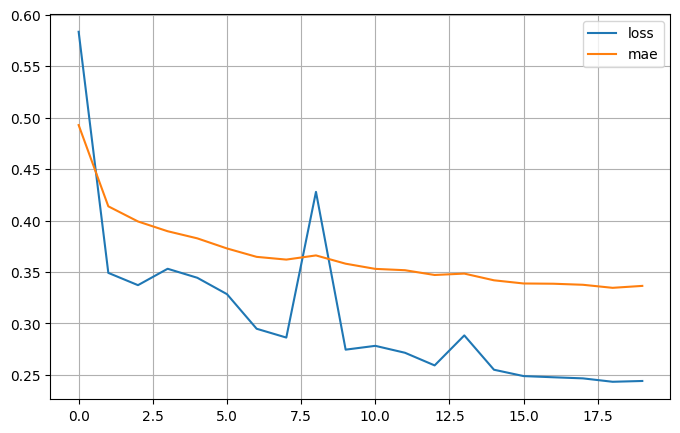

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 2) # set the vertical range to [0-1]
plt.show()

In [7]:
mse_test = final_model.evaluate(X_test_scaled, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2791 - mae: 0.3535


# Nova seção